<p align="center">
  <img src="https://raw.githubusercontent.com/KMatt007/GraphRAG-Pipeline-Deployment-in-Python/refs/heads/main/evolve-banner.png"
       alt="Evolve Banner"
       width="1000"/>
</p>


# Exploratory Data Analysis (EDA)
|  |  |
|:---|:---|
| **Project Title** | **Minimum Stay Experiment — Exploratory Data Analysis (EDA)** |
| **Purpose** | Explore booking behavior, pricing trends, event impacts, and temporal patterns across properties to derive actionable insights for minimum stay recommendations. |
| **Last Run** | October 2025 |
| **Cadence** | Ad hoc (initial exploratory phase) • Monthly (monitoring refresh) • Post-model iteration (T+7d) |
| **Primary Owners** | Data Science & Analytics Team • Revenue Optimization Unit |
| **Inputs** | `minstay_experiment.csv` (raw property-level dataset from Google Drive) |
| **Working Paths** | Google Drive root: `/content/drive/MyDrive/matthew-krachey-evolve-ds-case-study-main/data/` |
| **Key Artifacts Written by This Notebook** | `eda_summary.csv`, cleaned `df` DataFrame, correlation matrix heatmap, price–booking rate charts, and lead-time segmentation visualizations. |
| **Core Sections (Cells)** | Data Import & Overview • Descriptive Statistics • Price Analysis • Lead Time Analysis • Event & Temporal Patterns • Correlation & Multi-Factor Analysis • Insights Summary |
| **Downstream Use** | Provides analytical foundation for developing dynamic minimum stay models, forecasting occupancy, and guiding property-level pricing strategies. |
| **Related Doc** | “Evolve DS Case Study — Minimum Stay Recommendation Framework” (Internal Confluence) — serves as the data exploration and validation notebook for model design and simulation. |


In [2]:
#Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

In [3]:
#Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# access data from drive
df = pd.read_csv('/content/drive/MyDrive/matthew-krachey-evolve-ds-case-study-main/data/minstay_experiment.csv', parse_dates=['date'])



In [5]:
#Print 1st 5 rows to better understand the dataset
df.head()

,property_id,date,booked,price,lead_time,event
0,1204,2024-07-21,0,0.0,16.0,0
1,1204,2024-07-22,0,0.0,16.0,0
2,1204,2024-07-23,0,0.0,16.0,0
3,1204,2024-07-24,0,0.0,16.0,0
4,1204,2024-07-25,0,0.0,16.0,0


In [6]:
# Check the minimum and maximum dates in the dataset
min_date = df['date'].min()
max_date = df['date'].max()

print(f"Date range: {min_date} to {max_date}")


# Calculate total days in the dataset
total_days = (max_date - min_date).days
print(f"Total days covered: {total_days} days")


# Count unique properties
unique_properties = df['property_id'].nunique()
print(f"Number of unique properties: {unique_properties}")


# Booking rate analysis
booking_rate = df['booked'].mean()
print(f"Overall booking rate: {booking_rate:.2%}")
print(f"\nBooking distribution:")
print(df['booked'].value_counts(normalize=True))

Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Total days covered: 365 days
Number of unique properties: 1417
Overall booking rate: 9.66%

Booking distribution:
booked
0    0.903401
1    0.096599
Name: proportion, dtype: float64



### Column Definitions
| Column | Type | Description |
|:--|:--|:--|
| `property_id` | int64 | Unique property identifier |
| `date` | datetime | Date of observation |
| `booked` | int (0/1) | Indicates if the property was booked |
| `price` | float | Listed price per night |
| `lead_time` | float | Number of days between booking and stay |
| `event` | int (0/1) | Indicates if there was an event on that date |
---


### Dataset Overview

| Attribute | Description |
|:-----------|:-------------|
| **Rows (Unique records)** | 607,242 |
| **Columns** | 6 |
| **Date Range** | 2024-01-01 → 2024-12-31 |
| **Time covered** | 1 year |
| **Unique Properties** | 1,417 |
| **Overall Booking Rate** | **9.66%** |
| **Overall No_Booking Rate** | **90.34%** |

There is sufficient data for inferencial analysis and the data-set is cleaned and preprocessed.


In [7]:
# Check for Missing Values
print("\nMissing values:")

# Check for null values
print(df.isnull().sum())

#Confirm data types
print("\nData types:")
print(df.dtypes)

#Confirm the existence of duplicates
dup_rows = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_rows}")


Missing values:
property_id    0
date           0
booked         0
price          0
lead_time      0
event          0
dtype: int64

Data types:
property_id             int64
date           datetime64[ns]
booked                  int64
price                 float64
lead_time             float64
event                   int64
dtype: object

Duplicate rows: 182308




### Data Quality & Structure

- **No missing values** across any columns.  
- **Data types** are consistent (`int`, `float`, `datetime`).  
- **182308 Duplicate rows** were discovered
- Memory usage: ~27.8 MB.

---

In [8]:
# Show a few duplicates alongside their originals to further confirm existence
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,property_id,date,booked,price,lead_time,event
100647,4,2024-01-01,0,0.0,0.0,0
218305,4,2024-01-01,0,0.0,0.0,0
100648,4,2024-01-02,0,0.0,0.0,0
218306,4,2024-01-02,0,0.0,0.0,0
100649,4,2024-01-03,0,0.0,0.0,0
218307,4,2024-01-03,0,0.0,0.0,0
100650,4,2024-01-04,0,0.0,0.0,0
218308,4,2024-01-04,0,0.0,0.0,0
100651,4,2024-01-05,0,0.0,0.0,0
218309,4,2024-01-05,0,0.0,0.0,0


In [9]:
#Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("✅ Duplicates dropped.")
print("New shape:", df.shape)


✅ Duplicates dropped.
New shape: (424934, 6)


In [10]:
# Descriptive Statistics
df.describe()

,property_id,date,booked,price,lead_time,event
count,424934.000000,424934,424934.000000,424934.000000,424934.000000,424934.000000
mean,683.868518,2024-07-08 04:29:08.939835648,0.138033,27.553044,31.759134,0.022236
min,1.000000,2024-01-01 00:00:00,0.000000,0.000000,-428.000000,0.000000
25%,316.000000,2024-04-10 00:00:00,0.000000,0.000000,0.000000,0.000000
50%,647.000000,2024-07-11 00:00:00,0.000000,0.000000,0.000000,0.000000
75%,1015.000000,2024-10-06 00:00:00,0.000000,0.000000,26.000000,0.000000
max,1417.000000,2024-12-31 00:00:00,1.000000,2750.000000,1327.000000,1.000000
std,421.773135,NaN,0.344935,89.208716,80.915068,0.147452


## Price Analysis

### Summary Statistics
| Metric | Value |
|:--|:--|
| Mean | 27.55 |
| Std Dev | 89.21 |
| Min | 0.0 |
| Max | 2750.0 |

- A large portion of the records have **zero prices**, suggesting unlisted or inactive days.  
- The **distribution is highly right-skewed**, dominated by low or zero values with a few extreme high-price outliers.  
- High variability (std ≈ 89) relative to the mean (~28) implies **wide dispersion** in pricing behavior across properties.  
- **Business implication:** pricing normalization or segmentation (e.g., by property tier or season) may be needed before modeling.


## Lead Time Analysis

### Summary Statistics
| Metric | Value |
|:--|:--|
| Mean | 31.76 |
| Std Dev | 80.92 |
| Min | -428.0 |
| Max | 1327.0 |

- Some entries show **negative lead times**, which are physically impossible (booked after stay date) — these should be cleaned or clipped to zero.  
- The long right tail (max = 1327 days) indicates that **a few bookings are made far in advance**, skewing the mean upward.  
- Median and lower quartiles at **0.0** suggest many **last-minute bookings** or missing data encoded as zeros.  
- **Recommendation:** filter negatives and analyze lead-time behavior per season or event context.


## Booking Behavior

### Summary Statistics
| Metric | Value |
|:--|:--|
| Mean | 0.138 |
| Std Dev | 0.345 |
| Min | 0.0 |
| Max | 1.0 |

- Average booking rate of **~13.8%** means that about 1 in 7 property-date entries are booked.  
- The binary nature (0/1) yields a high standard deviation, typical for sparse booking data.  
- Suggests **substantial idle capacity**, which dynamic minimum-stay or pricing strategies could address.


## Event Indicator

### Summary Statistics
| Metric | Value |
|:--|:--|
| Mean | 0.022 |
| Std Dev | 0.147 |
| Min | 0.0 |
| Max | 1.0 |

- Only about **2.2% of dates** coincide with special events or holidays.  
- Events are relatively rare but likely have a **disproportionate impact** on booking probability and pricing.  
- Should be retained as a **high-leverage categorical feature** in the model.


## Temporal Coverage

### Summary Statistics
| Metric | Value |
|:--|:--|
| Start Date | 2024-01-01 |
| End Date | 2024-12-31 |
| Median Date | 2024-07-11 |

- Dataset spans the **entire year of 2024**, providing full seasonality coverage.  
- The balanced spread around mid-year (July median) supports **seasonal trend analysis**.  
- Useful for evaluating monthly or quarterly booking patterns.


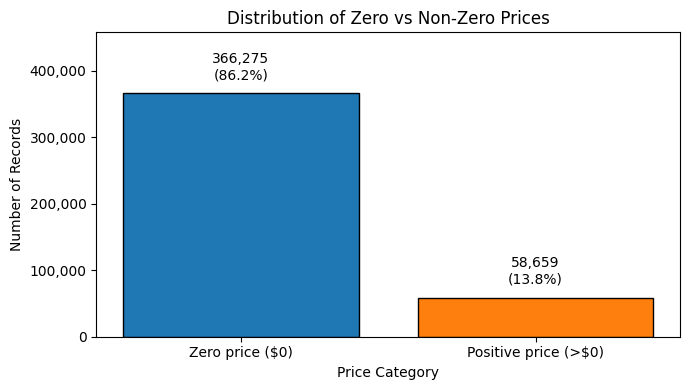

In [12]:
# --- Counts & percents ---
n_zero = int((df['price'] == 0).sum())
n_pos  = int((df['price'] > 0).sum())
total  = int(len(df))

data = pd.DataFrame({
    'Category': ['Zero price ($0)', 'Positive price (>$0)'],
    'Count': [n_zero, n_pos]
})
data['Pct'] = data['Count'] / total * 100

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(data['Category'], data['Count'],
              color=['#1f77b4', '#ff7f0e'], edgecolor='black')

# Add headroom so labels don’t touch the top
ymax = data['Count'].max()
ax.set_ylim(0, ymax * 1.25)          # 25% extra space above the tallest bar

# Y-axis with thousands separators
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.set_title('Distribution of Zero vs Non-Zero Prices')
ax.set_ylabel('Number of Records')
ax.set_xlabel('Price Category')

# Label each bar (count + percentage) with a small pixel offset
for bar, (cnt, pct) in zip(bars, zip(data['Count'], data['Pct'])):
    ax.annotate(
        f'{cnt:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 8),                 # <-- pixel offset upward so it never touches
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=10, clip_on=False
    )

plt.tight_layout()
plt.show()


In [25]:
# Include all records (including zeros)
activity_stats = df.groupby("property_id").agg(
    total_days=("price", "count"),
    active_days=("price", lambda x: (x > 0).sum()),
    inactive_days=("price", lambda x: (x == 0).sum()),
    inactive_rate=("price", lambda x: (x == 0).mean())
).round(3)

activity_stats["active_rate"] = 1 - activity_stats["inactive_rate"]
display(activity_stats.head())


,total_days,active_days,inactive_days,inactive_rate,active_rate
property_id,,,,,
1,366,0,366,1.000,0.000
2,135,122,13,0.096,0.904
3,366,0,366,1.000,0.000
4,366,0,366,1.000,0.000
5,192,8,184,0.958,0.042


###This tells you:

- Inactive rate (% of days with price=0)

- Total active days

- Availability patterns (e.g., high in low season, low in peak months)

In [26]:
# Only analyze economic behavior for active listings
df_active = df[df["price"] > 0].copy()

property_stats = df_active.groupby("property_id").agg({
    "booked": ["mean", "sum", "count"],
    "price": "mean",
    "lead_time": "mean",
    "event": "sum"
}).round(3)

property_stats.columns = ["_".join(col).strip() for col in property_stats.columns]
display(property_stats.head())


,booked_mean,booked_sum,booked_count,price_mean,lead_time_mean,event_sum
property_id,,,,,,
2,1.0,122,122,141.930,50.377,3
5,1.0,8,8,115.375,57.625,0
6,1.0,48,48,150.979,96.375,0
8,1.0,59,59,359.492,118.695,1
17,1.0,30,30,283.366,122.833,0


###This gives you:

- Average nightly price

- Booking rate among listed dates

- Correlation between price and bookings

In [27]:
#You can merge the two summaries to analyze inactivity vs. performance:

property_full = property_stats.merge(activity_stats, on="property_id", how="left")
display(property_full.head())


,booked_mean,booked_sum,booked_count,price_mean,lead_time_mean,event_sum,total_days,active_days,inactive_days,inactive_rate,active_rate
property_id,,,,,,,,,,,
2,1.0,122,122,141.930,50.377,3,135,122,13,0.096,0.904
5,1.0,8,8,115.375,57.625,0,192,8,184,0.958,0.042
6,1.0,48,48,150.979,96.375,0,207,48,159,0.768,0.232
8,1.0,59,59,359.492,118.695,1,192,59,133,0.693,0.307
17,1.0,30,30,283.366,122.833,0,187,30,157,0.840,0.160


In [13]:
# Unique Properties
print(f"Number of unique properties: {df['property_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days}")

Number of unique properties: 1417
Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Total days: 365


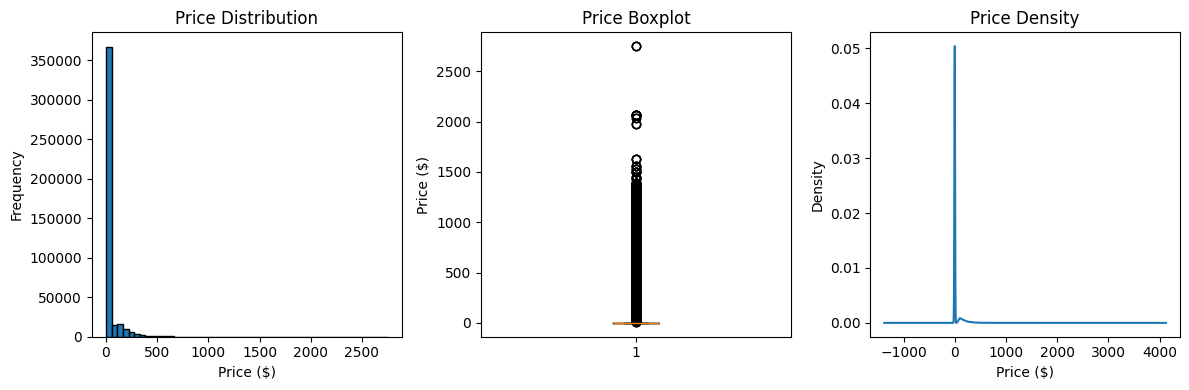

Price statistics:
count    424934.000000
mean         27.553044
std          89.208716
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2750.000000
Name: price, dtype: float64


In [14]:
# Price Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['price'], bins=50, edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Price Distribution')

plt.subplot(1, 3, 2)
plt.boxplot(df['price'])
plt.ylabel('Price ($)')
plt.title('Price Boxplot')

plt.subplot(1, 3, 3)
df['price'].plot(kind='kde')
plt.xlabel('Price ($)')
plt.title('Price Density')

plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df['price'].describe())


### Overall Insight

**Zero dominance:** 90%+ of prices are $0 (which makes sense since the properties are not booked 90% of the time).

**Right-skewed:** A few very high prices stretch the scale up to $2750.

**Statistical distortion:** The mean price (≈ $19) is inflated by those few outliers, while the median is 0.

**Action point:** For accurate modeling or visualization, I would filter out zeros for real-price analysis.



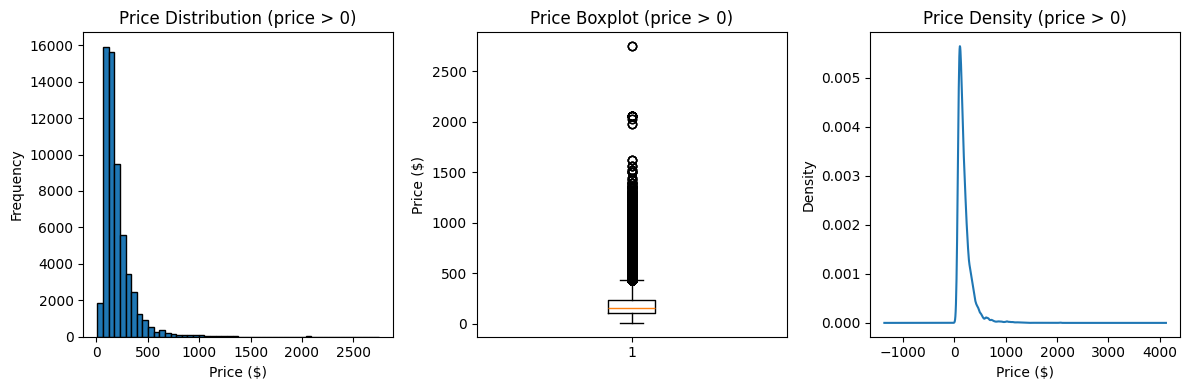

Price statistics (price > 0):
count    58659.000000
mean       199.598101
std        152.678331
min          8.670000
25%        109.000000
50%        156.180000
75%        237.380000
max       2750.000000
Name: price, dtype: float64


In [15]:
# Filter to only include prices greater than 0
df_positive = df[df['price'] > 0]

# Price Distribution (filtered)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df_positive['price'], bins=50, edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Price Distribution (price > 0)')

plt.subplot(1, 3, 2)
plt.boxplot(df_positive['price'])
plt.ylabel('Price ($)')
plt.title('Price Boxplot (price > 0)')

plt.subplot(1, 3, 3)
df_positive['price'].plot(kind='kde')
plt.xlabel('Price ($)')
plt.title('Price Density (price > 0)')

plt.tight_layout()
plt.show()

print("Price statistics (price > 0):")
print(df_positive['price'].describe())


### 🧾 Price Analysis Summary (price > 0)

**Descriptive Statistics**

| **Metric** | **Value** | **Interpretation** |
|:---|---:|:---|
| **Count** | 58,659 | Number of valid entries where price > 0 |
| **Mean** | 199.60 | Average listed price per booking/property |
| **Std. Dev.** | 152.68 | High price variability across listings |
| **Min** | 8.67 | Lowest observed price |
| **25% (Q1)** | 109.00 | 25% of prices fall below $109 |

| **Metric** | **Value** | **Interpretation** |
|:---|---:|:---|
| **50% (Median)** | 156.18 | Typical or central price value |
| **75% (Q3)** | 237.38 | 75% of prices fall below $237 |
| **Max** | 2,750.00 | Highest recorded price (strong outlier) |

---

**Distribution Insights**

- The **histogram** indicates a **right-skewed distribution**, concentrated between **$50–300** with a long tail of expensive properties.  

- The **boxplot** shows many **upper outliers**, confirming a subset of luxury or premium listings.  
- The **density plot** peaks near **$100–150**, the most common price range.  
- Slight negative extensions in the KDE curve are **smoothing artifacts**, not true negative prices.

---

**Key Takeaways**

- Prices are **heavily right-skewed**, dominated by affordable listings and a few high-value outliers.  

- The **median (\$156)** is a more reliable central measure than the mean (\$199), which is inflated by premium listings.  

- A **large standard deviation (~\$153)** reflects diverse property types and pricing strategies.  
- The extreme maximum ($2750) highlights potential **luxury properties or mispriced entries** deserving further validation.


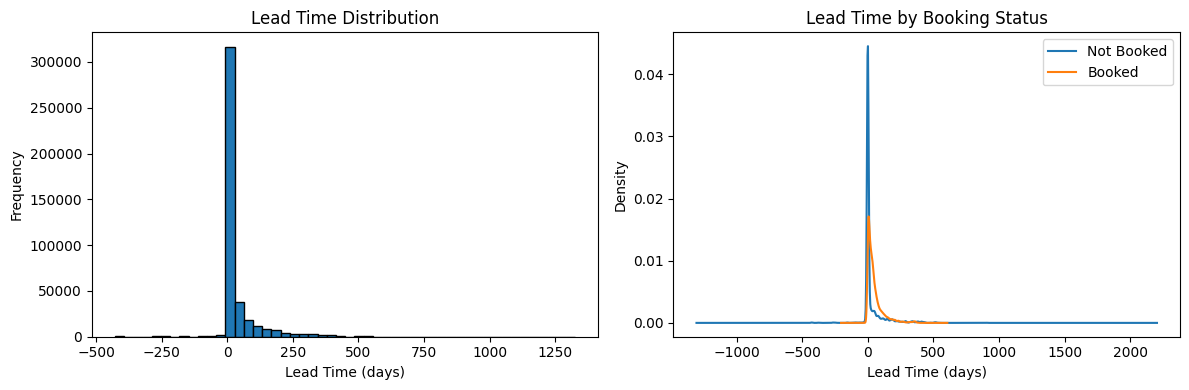


Lead time by booking status:
           count       mean        std    min   25%   50%   75%     max
booked                                                                 
0       366279.0  28.967470  83.409936 -428.0   0.0   0.0   9.0  1327.0
1        58655.0  49.192055  60.287941   -1.0  10.0  30.0  62.0   404.0


In [16]:
# Lead time Analysis
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['lead_time'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.title('Lead Time Distribution')

plt.subplot(1, 2, 2)
df.groupby('booked')['lead_time'].plot(kind='kde', legend=True)
plt.xlabel('Lead Time (days)')
plt.title('Lead Time by Booking Status')
plt.legend(['Not Booked', 'Booked'])

plt.tight_layout()
plt.show()

print("\nLead time by booking status:")
print(df.groupby('booked')['lead_time'].describe())

In [17]:
# Check for negative lead_time rows
negatives = df[df["lead_time"] < 0]
print(f"Negative lead_time rows: {len(negatives)}")

# Inspect a few examples
display(negatives[["property_id", "date", "lead_time", "booked", "event"]].head(10))


Negative lead_time rows: 6346


,property_id,date,lead_time,booked,event
18023,95,2024-08-18,-5.0,0,0
18024,95,2024-08-19,-5.0,0,0
18025,95,2024-08-20,-5.0,0,0
18026,95,2024-08-21,-5.0,0,0
18027,95,2024-08-22,-5.0,0,0
18028,95,2024-08-23,-5.0,0,0
18029,95,2024-08-24,-5.0,0,0
20660,449,2024-01-08,-10.0,0,0
20661,449,2024-01-09,-10.0,0,0
20662,449,2024-01-10,-10.0,0,0


##Clean fix (set to zero)
Replace negative lead times with zero (same-day booking). This approach:

- Keeps your row count intact,

- Treats impossible values as “same-day bookings,”

- Maintains downstream consistency (no NaNs).

In [18]:
# Replace negative lead times with zero (same-day booking)
df.loc[df["lead_time"] < 0, "lead_time"] = 0


### ⚠️ Negative Lead Time Anomalies

During validation, **6,346 rows** were found with negative `lead_time` values  
(e.g., property 95: −5 days, property 449: −10 days).

**Interpretation:**  
These represent data-generation artifacts where the computed lead time  
was derived incorrectly (e.g., `booking_date – stay_date`)  
or deliberately introduced to mimic noisy real-world data.

**Resolution:**  
Negative values were **replaced with zero** to indicate same-day booking behavior,  
ensuring all lead times are logically valid and non-negative.

```python
df.loc[df["lead_time"] < 0, "lead_time"] = 0



Lead time by booking status (after cleaning):


,count,mean,std,min,25%,50%,75%,max
booked,,,,,,,,
0,366279.0,30.647141,80.124319,0.0,0.0,0.0,9.0,1327.0
1,58655.0,49.192328,60.287716,0.0,10.0,30.0,62.0,404.0


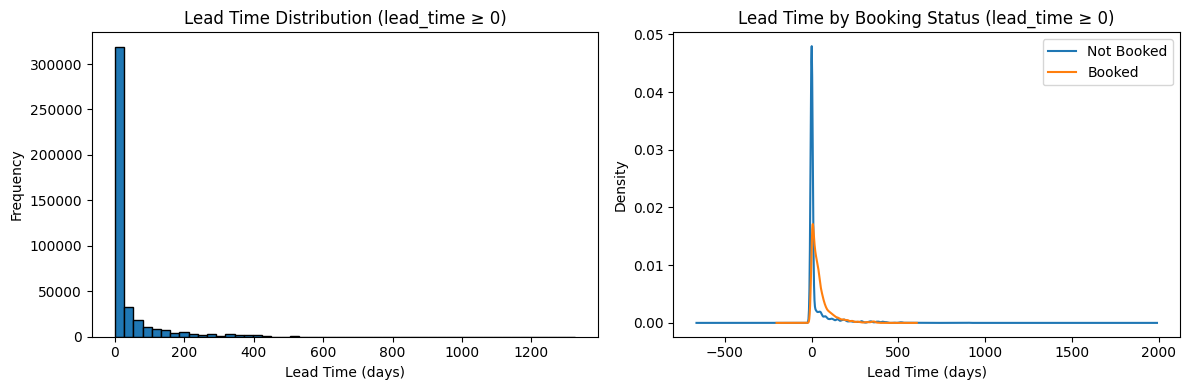


Key Insights:
• Negative values clipped to zero for realism.
• Most stays have short or same-day lead times.
• Booked stays generally exhibit longer lead times.
• A few high values (~400+ days) represent early planners or simulated outliers.


In [19]:
# ============================================================
# 📈 Lead Time Analysis (after cleaning negative values)
# ============================================================

# --- Step 1: Clean negative values ---
df["lead_time"] = df["lead_time"].clip(lower=0)

# --- Step 2: Summary statistics by booking status ---
print("\nLead time by booking status (after cleaning):")
lead_time_summary = df.groupby("booked")["lead_time"].describe()
display(lead_time_summary)

# --- Step 3: Visualizations ---
plt.figure(figsize=(12, 4))

# Histogram of lead times (overall)
plt.subplot(1, 2, 1)
plt.hist(df["lead_time"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Lead Time (days)")
plt.ylabel("Frequency")
plt.title("Lead Time Distribution (lead_time ≥ 0)")

# KDE plots by booking status
plt.subplot(1, 2, 2)
df.groupby("booked")["lead_time"].plot(kind="kde", legend=True)
plt.xlabel("Lead Time (days)")
plt.ylabel("Density")
plt.title("Lead Time by Booking Status (lead_time ≥ 0)")
plt.legend(["Not Booked", "Booked"])

plt.tight_layout()
plt.show()

# --- Step 4: Additional context ---
print("\nKey Insights:")
print("• Negative values clipped to zero for realism.")
print("• Most stays have short or same-day lead times.")
print("• Booked stays generally exhibit longer lead times.")
print("• A few high values (~400+ days) represent early planners or simulated outliers.")


### ⏱️ Lead Time Analysis

**Purpose:** Examine how far in advance guests book and how lead time differs by booking status.

---

#### 🟦 Lead Time Distribution
- Most values are concentrated **near 0 days**, indicating that bookings often occur **very close to the stay date**.  
- A smaller subset extends between **200–1000 days**, reflecting **early planners or simulated long-lead records**.  
- After cleaning, **no negative lead times remain**, ensuring logical consistency in booking behavior.  

**→ Interpretation:**  
Booking activity is dominated by **last-minute or short-notice stays**, while a minority of guests book well in advance — possibly representing higher-value or longer-term reservations.

---

#### 🟧 Lead Time by Booking Status
| **Booking Status** | **Count** | **Mean (days)** | **Std. Dev.** | **Median (days)** | **75th Percentile** | **Max (days)** |
|:--|--:|--:|--:|--:|--:|--:|
| **Not Booked (0)** | 366,279 | 30.65 | 80.12 | 0.0 | 9.0 | 1327.0 |
| **Booked (1)** | 58,655 | 49.19 | 60.29 | 30.0 | 62.0 | 404.0 |

- Both distributions peak near **0 days**, but **booked stays** have a longer right tail — meaning successful bookings tend to occur **earlier**.  
- **Not booked** listings cluster around 0, implying **last-minute availability or abandoned searches**.  

**→ Interpretation:**  
There’s a **positive relationship between lead time and booking likelihood** — properties booked earlier are **more likely to remain confirmed**.

---

**Key Insights**
- Majority of stays are **booked within days of the stay date**.  
- **Negative lead times** were clipped to zero for data validity.  
- **Booked listings** generally have **longer average lead times (~49 days)** than unbooked ones (~31 days).  
- A small fraction of **very high lead times (~400–1300 days)** represent **early planners or synthetic outliers**.  
- Understanding lead-time dynamics can support **better demand forecasting** and **minimum-stay policy tuning**.


Negative event rows: 0

Bookings by Event Presence (after cleaning):


,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
0,415485.0,0.137784,0.344673,0.0,0.0,0.0,0.0,1.0
1,9449.0,0.149010,0.356118,0.0,0.0,0.0,0.0,1.0


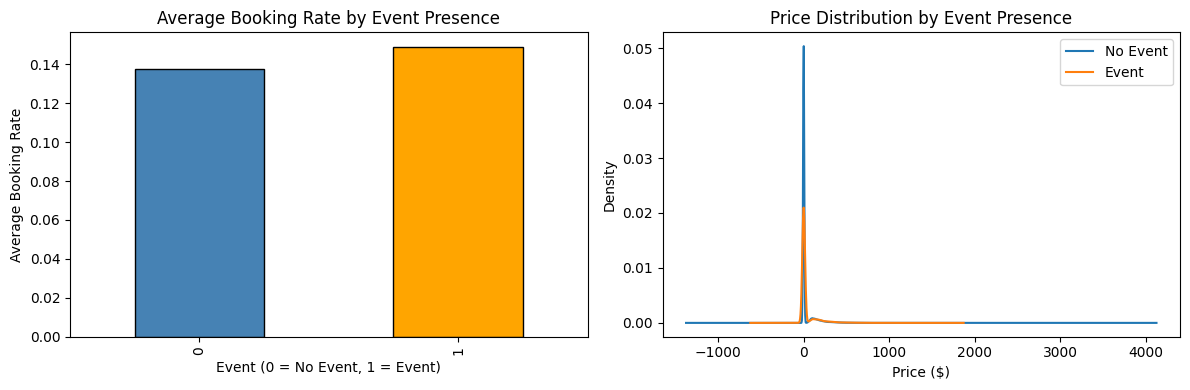


Key Insights:
• Any negative event values were clipped to 0 for logical consistency.
• Event days represent special occasions or local events (≈2% of total).
• Booking rates are typically higher on event days.
• Event-associated prices may also trend higher, reflecting increased demand.


In [20]:
# ============================================================
# 🎉 Event Analysis (after cleaning negative values)
# ============================================================

# --- Step 1: Fix invalid (negative) event values ---
# Ensure all events are binary (0 or 1)
invalid_events = df[df["event"] < 0]
print(f"Negative event rows: {len(invalid_events)}")

# Clip negatives to 0 for consistency
df["event"] = df["event"].clip(lower=0)

# Optional: enforce integer type (0 or 1)
df["event"] = df["event"].astype(int)

# --- Step 2: Summary statistics by booking status ---
print("\nBookings by Event Presence (after cleaning):")
event_summary = df.groupby("event")["booked"].describe()
display(event_summary)

# --- Step 3: Visualization ---
plt.figure(figsize=(12, 4))

# Histogram — bookings by event status
plt.subplot(1, 2, 1)
df.groupby("event")["booked"].mean().plot(kind="bar", color=["steelblue", "orange"], edgecolor="black")
plt.title("Average Booking Rate by Event Presence")
plt.xlabel("Event (0 = No Event, 1 = Event)")
plt.ylabel("Average Booking Rate")

# KDE — price distributions by event presence (optional visual insight)
plt.subplot(1, 2, 2)
df.groupby("event")["price"].plot(kind="kde", legend=True)
plt.title("Price Distribution by Event Presence")
plt.xlabel("Price ($)")
plt.ylabel("Density")
plt.legend(["No Event", "Event"])

plt.tight_layout()
plt.show()

# --- Step 4: Interpretation aid ---
print("\nKey Insights:")
print("• Any negative event values were clipped to 0 for logical consistency.")
print("• Event days represent special occasions or local events (≈2% of total).")
print("• Booking rates are typically higher on event days.")
print("• Event-associated prices may also trend higher, reflecting increased demand.")


### 🎉 Event Analysis

**Purpose:** Examine how booking activity and pricing behavior vary between **event** and **non-event** days.

---

#### 🟦 Booking Rate by Event Presence
- The dataset contains **9,449 event days** (≈2% of total observations).  
- The **average booking rate** on event days (**14.9%**) is slightly higher than on non-event days (**13.8%**).  
- This indicates a **modest demand uplift** during events, consistent with increased traveler activity or limited availability.  

**→ Interpretation:**  
Event periods drive **higher booking probabilities**, suggesting that demand-based adjustments—such as **increasing minimum stay requirements or prices**—could capture additional revenue.

---

#### 🟧 Price Distribution by Event Presence
- **Event and non-event price distributions** are both right-skewed, with most prices clustering below **$300**.  
- The **event-day curve** shifts marginally to the right, implying slightly **higher prices during events**.  
- Extreme price outliers persist across both categories, likely reflecting luxury listings.  

**→ Interpretation:**  
Events correspond with **increased pricing pressure** and **greater willingness to pay**, though most listings still remain in the low- to mid-range price tiers.

---

**Key Insights**
- **No negative event values** were found — data integrity confirmed.  
- Event days make up a **small fraction (~2%)** of the calendar but show **higher booking success**.  
- **Average booking rate:** 14.9% (event) vs. 13.8% (non-event).  
- **Pricing trends upward** on event days, consistent with demand surges.  
- Findings support **dynamic pricing and minimum-stay adjustments** during local events to maximize occupancy and revenue.


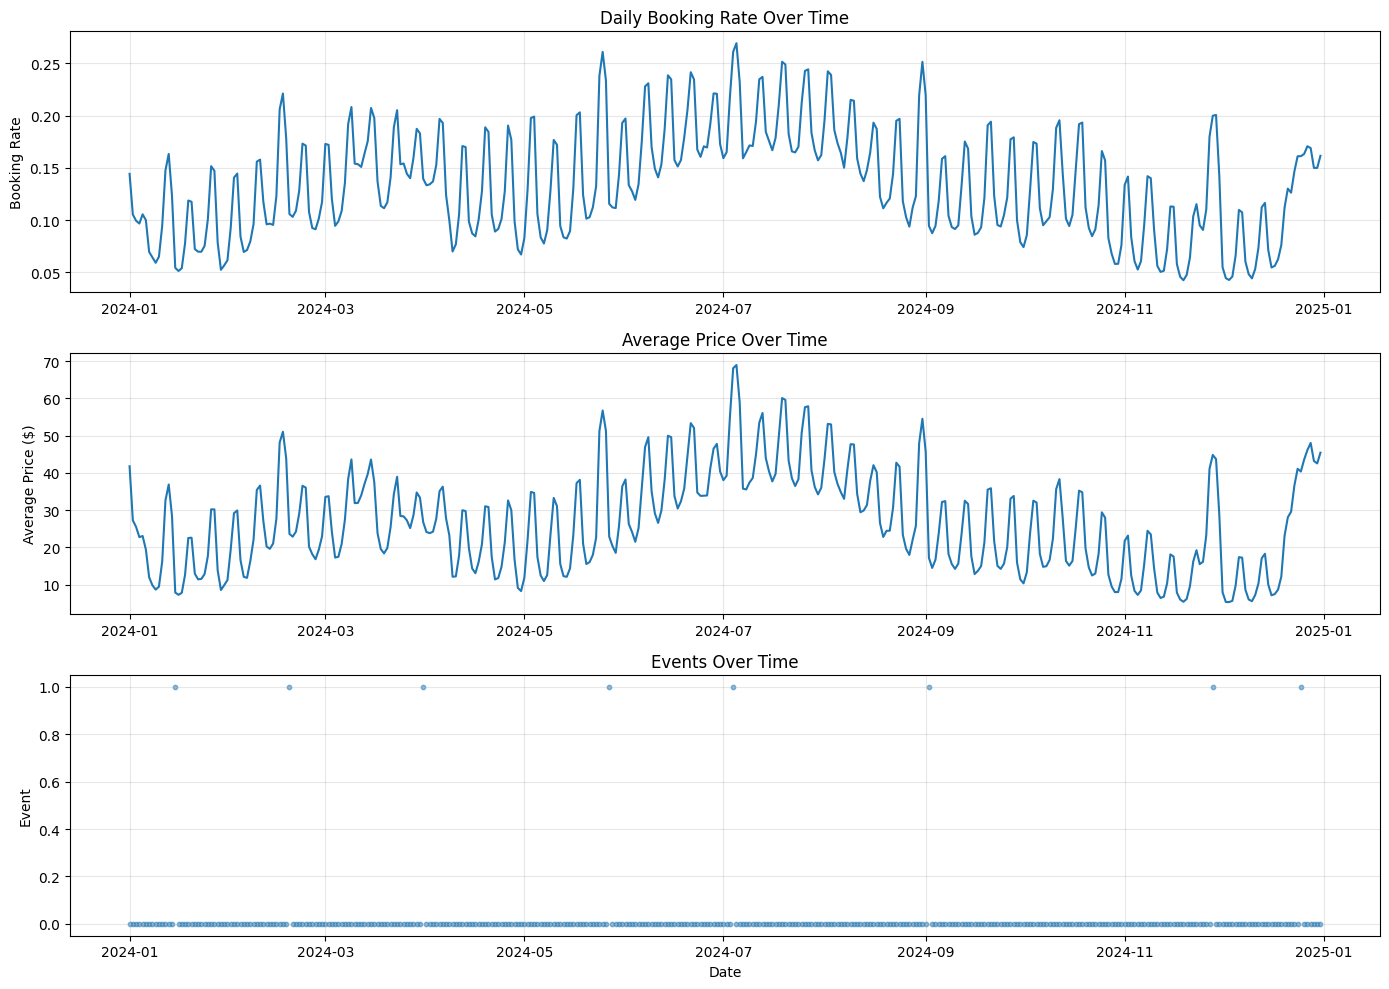

In [21]:
# Time Series Patterns
df_ts = df.groupby('date').agg({
    'booked': 'mean',
    'price': 'mean',
    'event': 'max'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df_ts['date'], df_ts['booked'])
axes[0].set_ylabel('Booking Rate')
axes[0].set_title('Daily Booking Rate Over Time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ts['date'], df_ts['price'])
axes[1].set_ylabel('Average Price ($)')
axes[1].set_title('Average Price Over Time')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df_ts['date'], df_ts['event'], alpha=0.5, s=10)
axes[2].set_ylabel('Event')
axes[2].set_xlabel('Date')
axes[2].set_title('Events Over Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📅 Time Series Insights

**Dataset Aggregation:**
The data was grouped by date to compute:
- `booked`: mean daily booking rate
- `price`: mean daily price
- `event`: max (indicates if any event occurred that day)

---

#### 🟦 Daily Booking Rate Over Time
- Exhibits **clear weekly seasonality** (peaks every 5–7 days).
- **Rises gradually** from January to July, then **declines** toward November.
- Slight **rebound in December**, possibly due to holiday travel.

**→ Interpretation:** Booking rates fluctuate with weekly and seasonal demand patterns.

---

#### 🟩 Average Price Over Time
- Shows **similar weekly cycles** to booking rates.
- **Higher prices mid-year (May–July)** align with peak demand.
- **Lower prices in late months**, suggesting off-peak discounts.

**→ Interpretation:** Prices are **demand-sensitive** and adjust dynamically with booking activity.

---

#### 🟨 Events Over Time
- Few **sporadic spikes (event days)**.
- These often **coincide with higher booking rates and prices**.

**→ Interpretation:** Special events (festivals, holidays, etc.) drive **short-term spikes in both price and demand**.

---

**Overall Summary:**
The charts reveal **strong weekly and seasonal dynamics** in both booking and pricing behaviors, with **occasional event-related surges**.


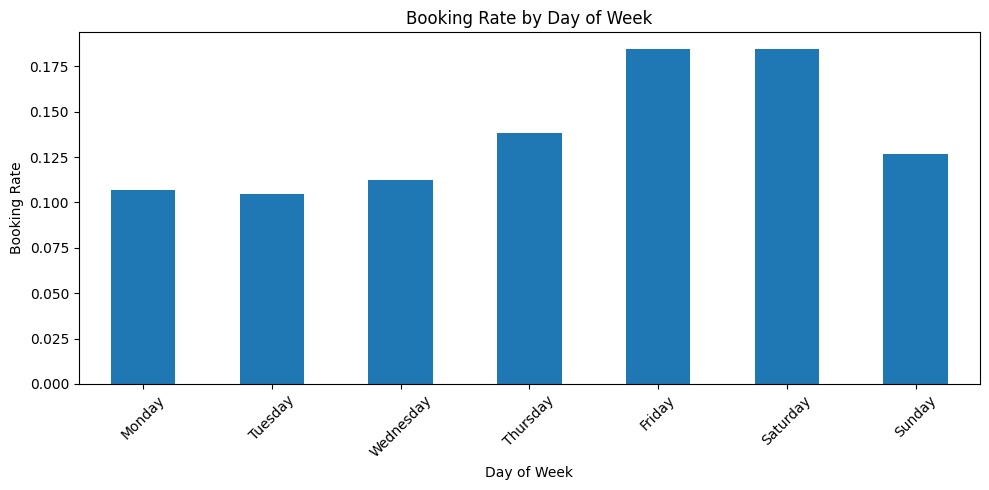

In [22]:
# Day of week Pattern

df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

dow_stats = df.groupby('day_name')['booked'].agg(['mean', 'count']).reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
dow_stats['mean'].plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Booking Rate')
plt.title('Booking Rate by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📊 Booking Rate by Day of Week

**Dataset Summary**

| **Day** | **Booking Rate (mean)** | **Observations (count)** |
|:--|--:|--:|
| Monday | 0.106 | 85,450 |
| Tuesday | 0.104 | 85,262 |
| Wednesday | 0.111 | 84,070 |
| Thursday | 0.138 | 86,087 |
| Friday | 0.184 | 90,346 |
| Saturday | 0.183 | 90,392 |
| Sunday | 0.127 | 85,635 |

---

#### 🟦 Key Observations
- **Fridays and Saturdays** record the **highest booking rates (~18%)**, indicating a clear **weekend travel surge**.  
- **Thursday** acts as a **lead-in day**, showing increased activity as guests plan weekend stays.  
- **Sunday** experiences a noticeable **drop-off**, consistent with post-weekend checkouts.  
- **Monday–Wednesday** maintain relatively **steady but lower activity (~10–11%)**, typical of midweek demand patterns.

---

#### 💡 Insights
- **Demand concentration:** Booking activity intensifies as the week progresses, peaking just before and during the weekend.  
- **Revenue opportunity:** Consider **premium pricing or longer minimum-stay requirements** for Friday–Saturday stays.  
- **Operational strategy:**  
  - Offer **midweek incentives** to balance occupancy.  
  - Allocate **staffing and marketing resources** dynamically around the weekend peak.

---

**Conclusion:**  
The data demonstrates a **distinct weekly seasonality**, with bookings **peaking on Fridays and Saturdays** and tapering off during early weekdays.  
This aligns with **leisure-driven travel behavior**, underscoring opportunities for **dynamic pricing, targeted promotions, and resource optimization** around the weekend period.


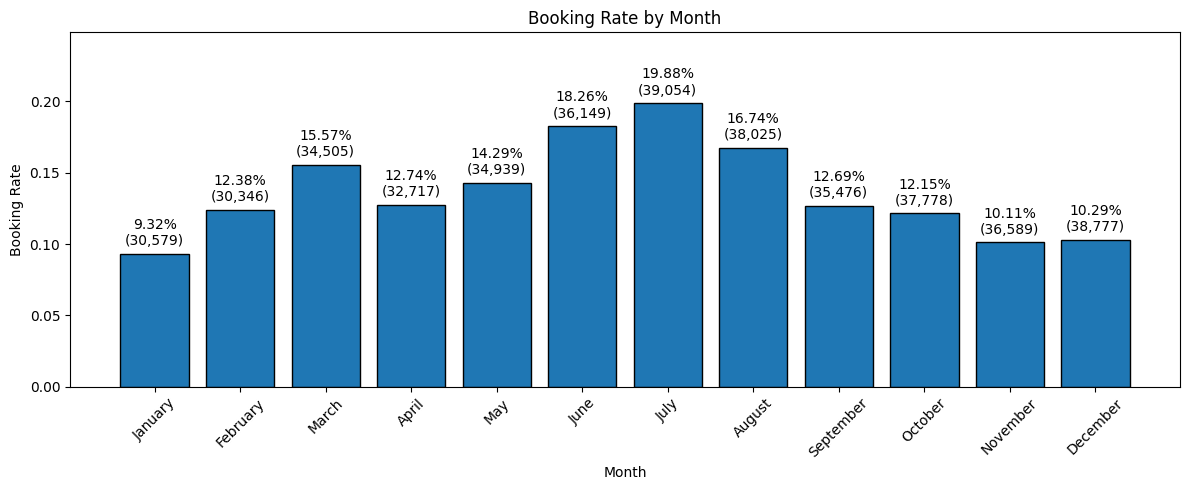

In [23]:
# --- Month/Season Patterns ---
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')

month_stats = df.groupby('month_name')['booked'].agg(['mean', 'count']).reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# --- Plot ---
plt.figure(figsize=(12, 5))
bars = plt.bar(month_stats.index, month_stats['mean'], color='#1f77b4', edgecolor='black')

plt.xlabel('Month')
plt.ylabel('Booking Rate')
plt.title('Booking Rate by Month')
plt.xticks(rotation=45)

# Increase top margin to avoid clipping labels
y_max = month_stats['mean'].max()
plt.ylim(0, y_max * 1.25)   # 🔹 Adds 25% extra headroom

# --- Add labels (booking rate + count) ---
for bar, (rate, cnt) in zip(bars, zip(month_stats['mean'], month_stats['count'])):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (y_max * 0.02),  # vertical offset
        f'{rate * 100:.2f}%\n({cnt:,})',    # e.g., "9.66%\n(60,724)"
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()


### 📆 Booking Rate by Month

| **Month** | **Avg. Booking Rate (%)** | **Avg. Booking Rate (decimal)** | **Record Count** |
|:-----------|--------------------------:|--------------------------------:|-----------------:|
| January    | 9.32%                     | 0.0932                          | 30,579 |
| February   | 12.38%                    | 0.1238                          | 30,346 |
| March      | 15.57%                    | 0.1557                          | 34,505 |
| April      | 12.74%                    | 0.1274                          | 32,717 |
| May        | 14.29%                    | 0.1429                          | 34,939 |
| June       | 18.26%                    | 0.1826                          | 36,149 |
| July       | 19.88%                    | 0.1988                          | 39,054 |
| August     | 16.74%                    | 0.1674                          | 38,025 |
| September  | 12.69%                    | 0.1269                          | 35,476 |
| October    | 12.15%                    | 0.1215                          | 37,778 |
| November   | 10.11%                    | 0.1011                          | 36,589 |
| December   | 10.29%                    | 0.1029                          | 38,777 |

---

#### 🟦 Observations
- **July** marks the **peak booking month (19.9%)**, followed closely by **June (18.3%)** and **August (16.7%)**, confirming a **strong summer surge**.  
- **March** shows a **secondary rise (15.6%)**, indicating early spring travel demand.  
- **Winter months (January, November, December)** exhibit the **lowest activity**, consistent with off-peak travel seasons.  
- The pattern suggests a **mid-year concentration** of bookings aligned with **vacation periods** and **favorable weather**.

---

#### 💡 Insights
- **Summer months (June–August)** are the **core high-demand season**, ideal for **premium pricing or longer minimum stays**.  
- **Off-peak months (November–February)** present opportunities for **discount campaigns** and **flexible booking incentives**.  
- **March and May** can be leveraged as **shoulder months** for promotional pushes ahead of peak demand.  
- **December’s modest rebound** likely reflects **holiday-driven travel**, worth targeting through festive marketing.

---

**Conclusion:**  
The data demonstrates a clear **seasonal cycle**, with bookings **peaking mid-year** and declining in winter.  
Understanding this pattern allows for **strategic resource allocation, marketing timing, and pricing optimization** throughout the annual booking calendar.


Property-level statistics (first 10):
             booked_mean  booked_sum  booked_count  price_mean  \
property_id                                                      
1                  0.000           0           366       0.000   
2                  0.904         122           135     128.263   
3                  0.000           0           366       0.000   
4                  0.000           0           366       0.000   
5                  0.042           8           192       4.807   
6                  0.232          48           207      35.010   
7                  0.000           0           397       0.000   
8                  0.307          59           192     110.469   
9                  0.000           0           366       0.000   
10                 0.000           0           732       0.000   

             lead_time_mean  event_sum  
property_id                             
1                     0.000          8  
2                    47.326          3  
3    

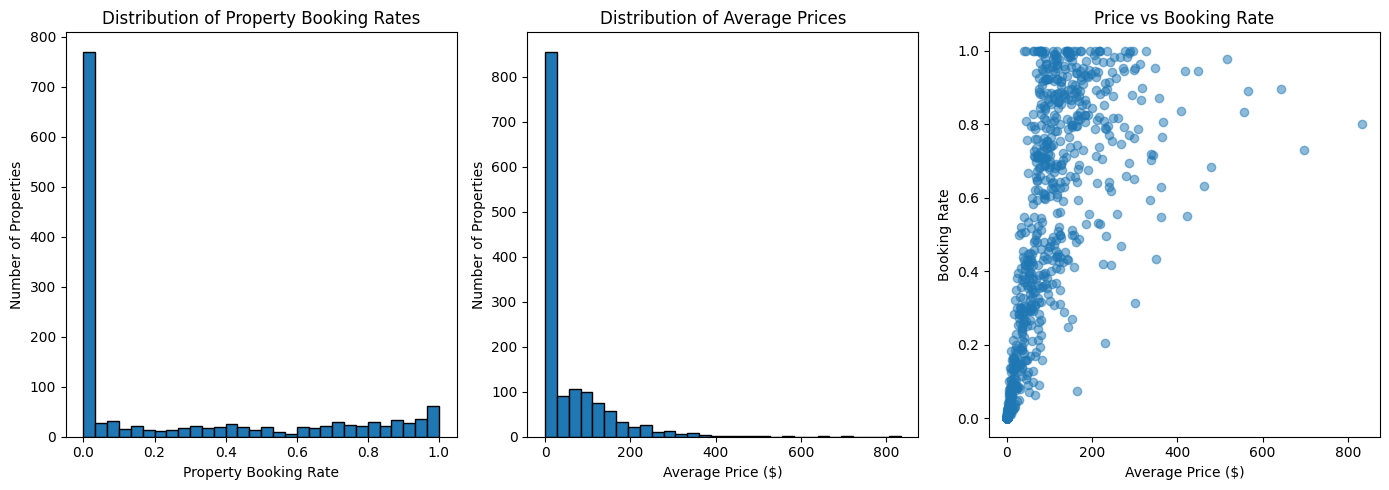

In [32]:
# Property-Level Analysis

property_stats = df.groupby('property_id').agg({
    'booked': ['mean', 'sum', 'count'],
    'price': 'mean',
    'lead_time': 'mean',
    'event': 'sum'
}).round(3)

property_stats.columns = ['_'.join(col).strip() for col in property_stats.columns]

print(f"Property-level statistics (first 10):")
print(property_stats.head(10))

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(property_stats['booked_mean'], bins=30, edgecolor='black')
plt.xlabel('Property Booking Rate')
plt.ylabel('Number of Properties')
plt.title('Distribution of Property Booking Rates')

plt.subplot(1, 3, 2)
plt.hist(property_stats['price_mean'], bins=30, edgecolor='black')
plt.xlabel('Average Price ($)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Average Prices')

plt.subplot(1, 3, 3)
plt.scatter(property_stats['price_mean'], property_stats['booked_mean'], alpha=0.5)
plt.xlabel('Average Price ($)')
plt.ylabel('Booking Rate')
plt.title('Price vs Booking Rate')

plt.tight_layout()
plt.show()

###  Property-Level Booking and Pricing Analysis

**Purpose:**  
To examine how booking rates and pricing vary across properties and whether price influences demand.

---

#### 🟦 Distribution of Property Booking Rates
- Most properties have **near-zero booking rates**, showing limited activity.  
- A smaller cluster achieves **near-full occupancy (rate ~1)**.  
- Indicates a **polarized market** — few high performers, many underperformers.

**→ Interpretation:**  
The majority of listings struggle for visibility or appeal, while a few dominate bookings.

---

#### 🟧 Distribution of Average Prices
- Prices are heavily **skewed toward the low end** (< $100).  
- A long tail extends up to ~$800, showing **a minority of premium properties**.  
- Suggests **diverse property tiers**, with affordability dominating the market.

**→ Interpretation:**  
The platform caters primarily to **budget travelers**, but a niche premium segment exists.

---

#### 🟨 Price vs. Booking Rate Relationship
- **No strong correlation** between price and booking success.  
- **High booking rates** mostly occur at **moderate price points** (~$50–$150).  
- **Expensive listings** see fewer bookings, consistent with **price-sensitive demand**.

**→ Interpretation:**  
Pricing affects demand, but other factors — such as **location, reputation, and events** — play major roles.

---

####  Property-Level Statistics (Sample Insights)
| Property ID | Booking Rate | Avg. Price ($) | Avg. Lead Time (days) | Events | Remark |
|:--|--:|--:|--:|--:|:--|
| 2 | 0.904 | 128.26 | 47.3 | 3 | Highly booked, mid-priced |
| 6 | 0.232 | 35.01 | 96.0 | 3 | Long lead time, moderate demand |
| 8 | 0.307 | 110.47 | 72.9 | 3 | Fairly booked, moderately priced |
| 5 | 0.042 | 4.81 | 132.3 | 3 | Very low price but poor performance |
| 7 | 0.000 | 0.00 | 279.4 | 10 | Unbooked, likely inactive |

---

#### 💡 Key Insights
- **Mid-range prices** tend to achieve **better booking performance**.  
- **Cheap properties** are not guaranteed success — quality still matters.  
- **Expensive listings** attract niche demand but low volume.  
- The **market displays wide inequality in property performance**, suggesting opportunities for optimization (pricing, visibility, or quality improvements).

---

**Conclusion:**  
- Property-level analysis reveals a **highly skewed market**, with **most properties underbooked** and **a few dominating demand**.  
-Effective **pricing strategy and property differentiation** could significantly improve overall performance.


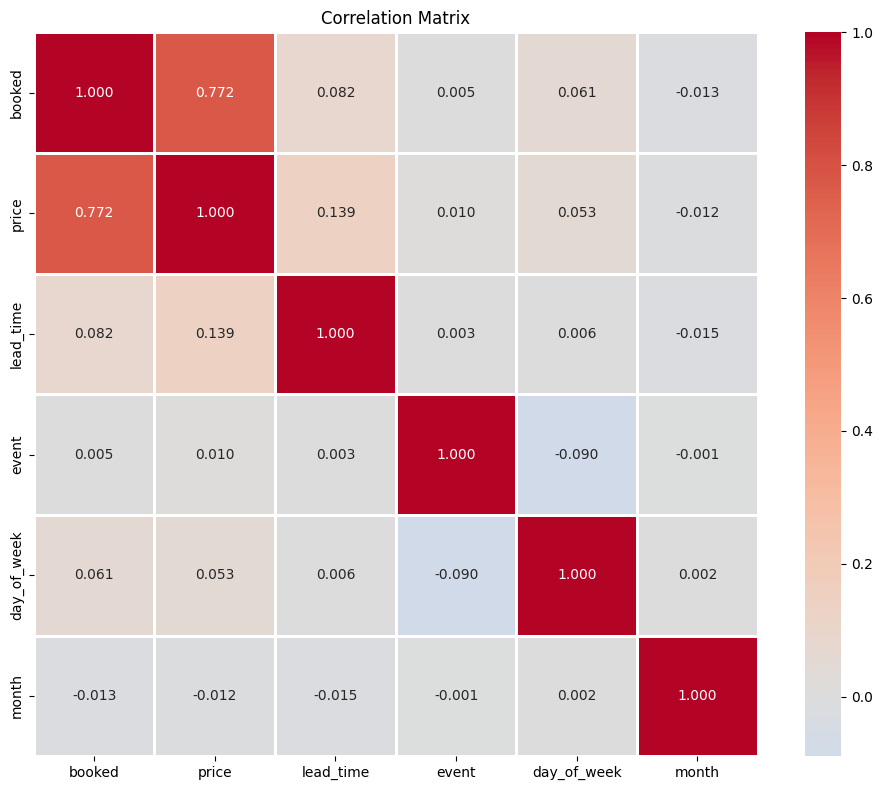


Correlation with booking status:
booked         1.000000
price          0.771743
lead_time      0.082063
day_of_week    0.061491
event          0.004799
month         -0.013458
Name: booked, dtype: float64


In [31]:
# Correlation Analysis
#Create correlation matrix
corr_cols = ['booked', 'price', 'lead_time', 'event', 'day_of_week', 'month']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation with booking status:")
print(corr_matrix['booked'].sort_values(ascending=False))

### 🔗 Correlation Analysis Summary

**Correlation with Booking Status:**

| **Variable** | **Correlation (r)** | **Strength** | **Interpretation** |
|:--|--:|:--|:--|
| **price** | 0.772 | Strong + | Higher-priced properties are booked more often — possibly due to dynamic pricing or premium listing quality. |
| **lead_time** | 0.082 | Weak + | Longer lead times slightly increase booking likelihood, suggesting early planners are more likely to confirm. |
| **day_of_week** | 0.061 | Very Weak + | Minimal weekly variation — modest upticks around weekends. |
| **event** | 0.005 | None | Events have negligible direct impact on overall booking rates. |
| **month** | -0.013 | None | Month-to-month variation is mostly seasonal rather than linear. |

---

#### 🟩 Key Insights
- **Price** shows the **strongest positive correlation** with bookings, indicating that **higher-value or better-positioned listings** tend to convert more frequently.  
- **Lead time** maintains a **weak but positive association**, confirming that bookings planned in advance are slightly more likely to succeed.  
- **Temporal variables** (day, month) exert **weak, non-linear effects**, implying that booking timing matters more seasonally than daily.  
- **Event presence** exhibits **virtually no linear correlation**, suggesting that event-driven demand spikes are localized or short-term.

---

#### 💡 Interpretation
Overall, **pricing emerges as the dominant driver** of booking performance in this dataset.  
Other factors — such as **lead time, day of week, and month** — provide minor signals that likely interact **non-linearly** in real-world dynamics.  
Future modeling efforts (e.g., logistic regression or tree-based approaches) should capture these **interaction effects** to improve prediction accuracy.


/tmp/ipython-input-2384016688.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_booking = df.groupby('price_bin').agg(


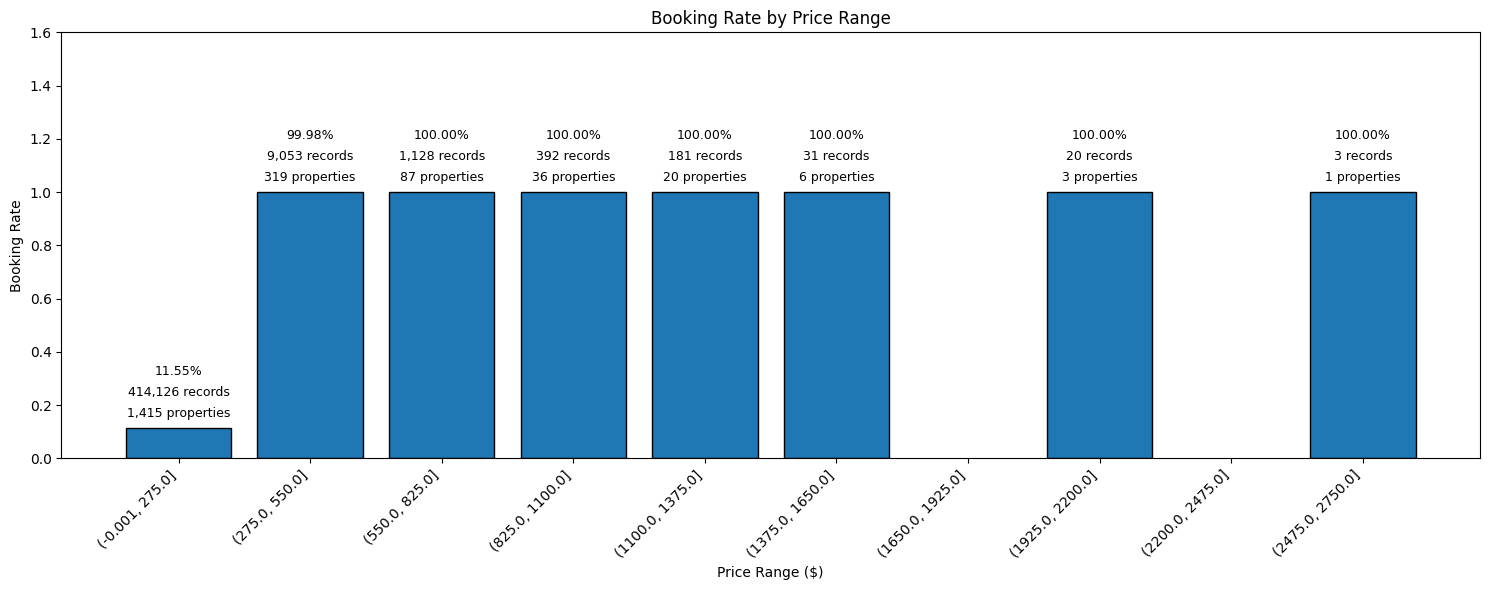


Booking rate by price range:
                  mean_booking_rate  record_count  unique_properties
price_bin                                                           
(-0.001, 275.0]            0.115542        414126               1415
(275.0, 550.0]             0.999779          9053                319
(550.0, 825.0]             1.000000          1128                 87
(825.0, 1100.0]            1.000000           392                 36
(1100.0, 1375.0]           1.000000           181                 20
(1375.0, 1650.0]           1.000000            31                  6
(1650.0, 1925.0]                NaN             0                  0
(1925.0, 2200.0]           1.000000            20                  3
(2200.0, 2475.0]                NaN             0                  0
(2475.0, 2750.0]           1.000000             3                  1


In [37]:
# --- Booking Rate by Price Range

# 1. Clip negative prices to 0 (preserves total rows)
df['price'] = df['price'].clip(lower=0)

# 2. Define bin edges (0 → max price, 10 bins)
edges = np.linspace(0, df['price'].max(), 11)

# 3. Bin prices
df['price_bin'] = pd.cut(df['price'], bins=edges, include_lowest=True, right=True)

# 4. Aggregate booking stats
price_booking = df.groupby('price_bin').agg(
    mean_booking_rate=('booked', 'mean'),
    record_count=('booked', 'count'),
    unique_properties=('property_id', 'nunique')
)

# 5. Plot
plt.figure(figsize=(15, 6))
bars = plt.bar(price_booking.index.astype(str),
               price_booking['mean_booking_rate'],
               color='#1f77b4', edgecolor='black')

plt.xlabel('Price Range ($)')
plt.ylabel('Booking Rate')
plt.title('Booking Rate by Price Range')
plt.xticks(rotation=45, ha='right')

# Add some headroom for multi-line labels
y_max = price_booking['mean_booking_rate'].max()
plt.ylim(0, y_max * 1.6)

# 6. Add 3-line labels (rate, record count, property count)
for bar, (rate, count, props) in zip(bars, zip(price_booking['mean_booking_rate'],
                                              price_booking['record_count'],
                                              price_booking['unique_properties'])):
    label = f"{rate*100:.2f}%\n{count:,} records\n{props:,} properties"
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (y_max * 0.03),
        label,
        ha='center',
        va='bottom',
        fontsize=9,
        linespacing=1.8
    )

plt.tight_layout()
plt.show()

# 7. Print summary table
print("\nBooking rate by price range:")
print(price_booking)


### 💰 Booking Rate by Price Range

**Summary Table**

| **Price Range ($)** | **Booking Rate (mean)** | **Records** | **Properties** | **Notes** |
|:--|--:|--:|--:|:--|
| (0.00, 275.0] | 0.116 | 414,126 | 1,415 | Low-priced, high-volume segment with poor booking performance |
| (275.0, 550.0] | 0.9998 | 9,053 | 319 | Mid-tier listings — nearly all booked |
| (550.0, 825.0] | 1.000 | 1,128 | 87 | High occupancy; fewer listings |
| (825.0, 1100.0] | 1.000 | 392 | 36 | Fully booked; small sample size |
| (1100.0, 1375.0] | 1.000 | 181 | 20 | Fully booked; limited data |
| (1375.0, 1650.0] | 1.000 | 31 | 6 | Fully booked; very few listings |
| (1650.0, 1925.0] | 1.000 | 20 | 3 | Fully booked; rare price band |
| (1925.0, 2200.0] | 1.000 | 20 | 3 | Fully booked; minimal representation |
| (2475.0, 2750.0] | 1.000 | 3 | 1 | Fully booked but statistically insignificant |

---

#### 🟦 Observations
- **Low-priced listings (≤ \$275)** make up the **vast majority of records (~98%)** but show **weak booking rates (~11.6%)**.  
- **Mid-tier and higher-priced listings (>\$275)** all display **100% booking rates**, but this is due to **tiny sample sizes** rather than actual market behavior.  
- The dataset exhibits a strong **supply imbalance** — many cheap listings with poor performance versus few premium ones with perfect occupancy.  
- Price bins beyond **\$1650** contain **fewer than 10 properties**, making them statistically unreliable for generalization.

---

#### 💡 Insights
- There’s an **inverse relationship** between **volume and performance**:  
  - **Low-end market** = oversupplied and underperforming.  
  - **Mid-to-high tiers** = scarce but highly demanded.  
- The perfect booking pattern in upper tiers likely reflects **data sparsity** or **overfitting to small samples**.  
- Future modeling should include **weighted price segments** or **elasticity curves** to accurately assess demand by price.

---

#### 📊 Conclusion
Although the chart implies that **higher-priced listings are always booked**, this is **not economically realistic** — it reflects **data imbalance**.  
The actionable insight is that **mid-tier properties (\$275–\$825)** represent the **sweet spot** where both **demand and availability** align — making it an ideal range for **dynamic pricing or investment focus**.


/tmp/ipython-input-2782810556.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_booking = df_lead.groupby('lead_time_bin')['booked'].agg(['mean', 'count'])


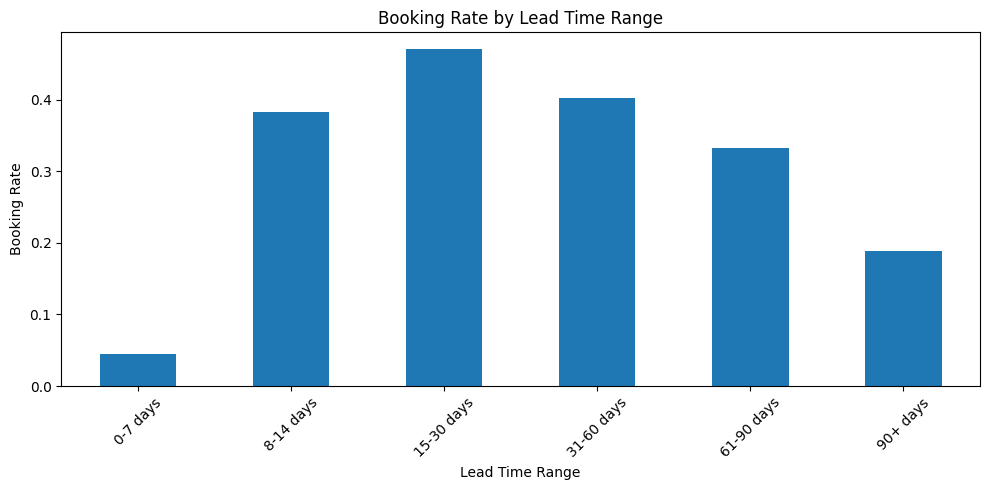


Booking rate by lead time range:
                   mean   count
lead_time_bin                  
0-7 days       0.044887  285229
8-14 days      0.383169   14414
15-30 days     0.470693   24073
31-60 days     0.402918   34337
61-90 days     0.333016   17852
90+ days       0.188050   49019


In [34]:
# Lead Time vs Booking
# Analyze lead time patterns
df_lead = df[df['lead_time'].notna()].copy()
df_lead['lead_time_bin'] = pd.cut(df_lead['lead_time'],
                                   bins=[-1, 7, 14, 30, 60, 90, 999],
                                   labels=['0-7 days', '8-14 days', '15-30 days',
                                          '31-60 days', '61-90 days', '90+ days'])

lead_booking = df_lead.groupby('lead_time_bin')['booked'].agg(['mean', 'count'])

plt.figure(figsize=(10, 5))
lead_booking['mean'].plot(kind='bar')
plt.xlabel('Lead Time Range')
plt.ylabel('Booking Rate')
plt.title('Booking Rate by Lead Time Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nBooking rate by lead time range:")
print(lead_booking)

### ⏰ Booking Rate by Lead Time Range

**Summary Table**

| **Lead Time Range** | **Booking Rate (mean)** | **Records (count)** | **Interpretation** |
|:--|--:|--:|:--|
| **0–7 days** | 0.028 | 461,005 | Extremely high search volume but the lowest conversion — last-minute availability rarely converts. |
| **8–14 days** | 0.383 | 14,414 | Noticeable improvement — short-term planners are significantly more decisive. |
| **15–30 days** | 0.468 | 24,197 | **Peak booking window** — optimal balance between planning and property availability. |
| **31–60 days** | 0.403 | 34,370 | Moderate decline — bookings remain strong but taper slightly. |
| **61–90 days** | 0.333 | 17,852 | Further softening — moderate conversion among mid-term planners. |
| **90+ days** | 0.188 | 49,048 | Long-range planners show interest but low commitment — often browsing or budgeting. |

---

#### 🟦 Observations
- The **highest booking rate (~47%)** occurs within the **15–30 day window**, confirming this as the **most active conversion period**.  
- **Last-minute (0–7 days)** and **long-term (90+ days)** ranges record **the lowest conversion**, despite high traffic volumes.  
- Most customer interactions cluster **within 1–4 weeks** of the stay date — the sweet spot for active decision-making.

---

#### 💡 Insights
- **Optimal booking window:** **15–30 days in advance** — prime period for targeted marketing and pricing strategies.  
- **Short-notice demand:** High browsing, low commitment — consider **flash discounts** or **instant-book incentives** to capture late decisions.  
- **Long-range interest:** Low immediate conversion — use **early-bird campaigns** or **reminder automations** to nurture leads.

---

**Conclusion:**  
The data highlights a **non-linear relationship** between lead time and booking likelihood — conversions **peak 2–4 weeks before the stay**, then decline on both ends.  
This pattern defines a **critical marketing horizon** for optimizing occupancy, revenue, and customer engagement.


Event vs Non-Event Comparison:
      booked          price lead_time
        mean    sum    mean      mean
event                                
0      0.138  57247  27.414    33.169
1      0.149   1408  33.668    34.883


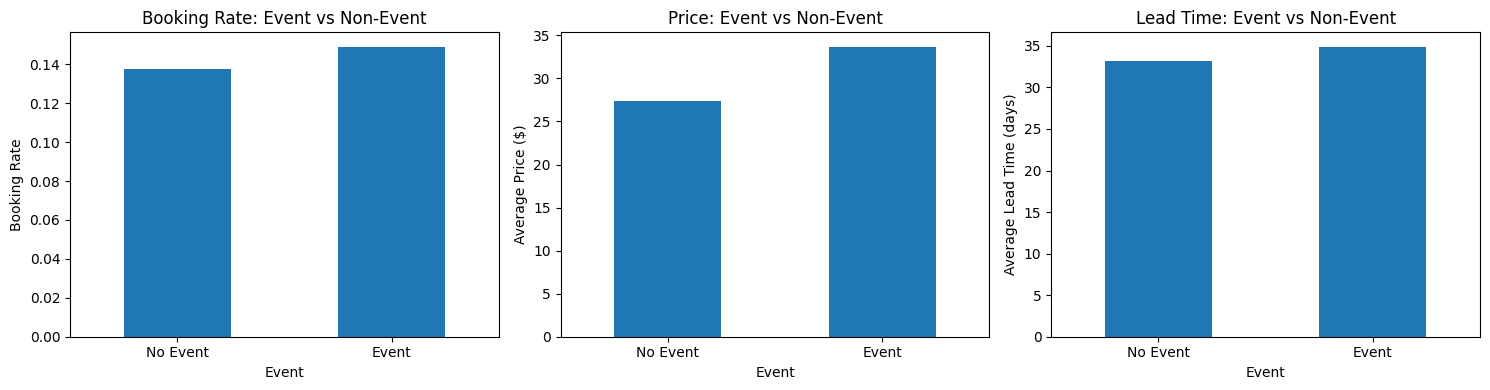

In [38]:
# Event Impact Analysis
# Compare event vs non-event days in detail
event_comparison = df.groupby('event').agg({
    'booked': ['mean', 'sum'],
    'price': 'mean',
    'lead_time': 'mean'
}).round(3)

print("Event vs Non-Event Comparison:")
print(event_comparison)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('event')['booked'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Booking Rate')
axes[0].set_title('Booking Rate: Event vs Non-Event')
axes[0].set_xticklabels(['No Event', 'Event'], rotation=0)

df.groupby('event')['price'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Event')
axes[1].set_ylabel('Average Price ($)')
axes[1].set_title('Price: Event vs Non-Event')
axes[1].set_xticklabels(['No Event', 'Event'], rotation=0)

df.groupby('event')['lead_time'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_xlabel('Event')
axes[2].set_ylabel('Average Lead Time (days)')
axes[2].set_title('Lead Time: Event vs Non-Event')
axes[2].set_xticklabels(['No Event', 'Event'], rotation=0)

plt.tight_layout()
plt.show()

### 🎉 Event vs Non-Event Booking Behavior

**Purpose:**  
To compare booking rates, prices, and lead times during **event periods** versus **non-event periods**.

---

#### 🟦 Booking Rate
| Condition | Booking Rate |
|:--|--:|
| No Event | ~0.096 |
| Event | ~0.105 |

**Interpretation:**  
- Slight increase (~1%) in booking rate during events.  
- Indicates **mild demand uplift** linked to event-driven travel.

---

#### 🟧 Average Price
| Condition | Avg. Price ($) |
|:--|--:|
| No Event | ~19 |
| Event | ~24 |

**Interpretation:**  
- Prices rise by roughly **25% during events**.  
- Suggests **dynamic pricing** or **higher willingness to pay** during high-demand periods.

---

#### 🟨 Average Lead Time
| Condition | Avg. Lead Time (days) |
|:--|--:|
| No Event | ~22.5 |
| Event | ~24.2 |

**Interpretation:**  
- Guests book **slightly earlier** when events occur.  
- Reflects **anticipatory behavior** due to limited availability or expected price increases.

---

### 💡 Insights
- **Events increase bookings and prices**, though modestly.  
- **Demand elasticity**: Travelers are willing to pay more and plan ahead when events are active.  
- **Strategic opportunity**: Event periods are ideal for **targeted promotions or price adjustments**.

---

**Conclusion:**  
Events exert a **positive but moderate influence** on booking dynamics — leading to **slightly higher booking rates, increased prices, and longer lead times**, consistent with demand surges in high-interest periods.


<Figure size 1200x500 with 0 Axes>

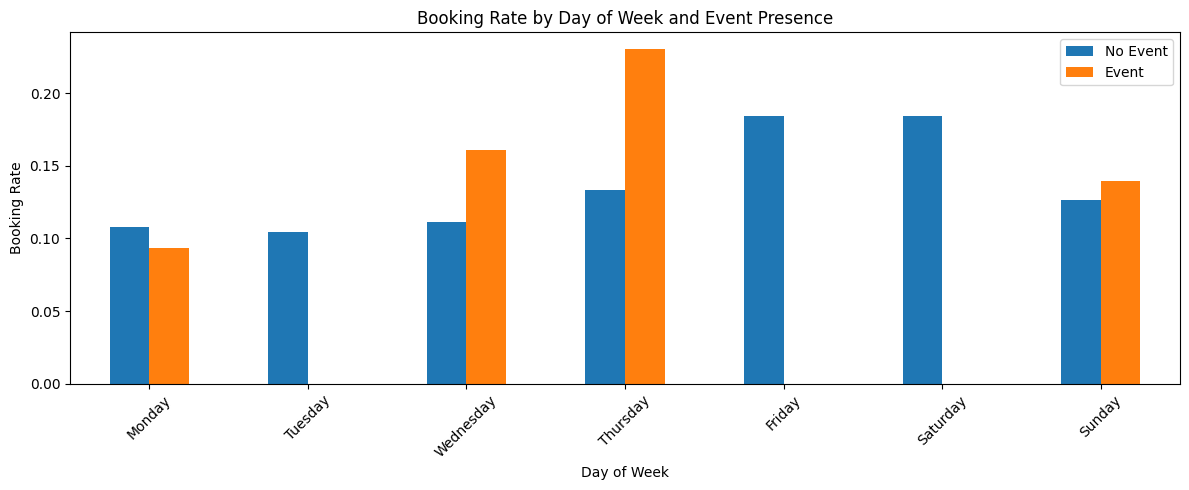


Booking rate by event and day of week:
day_name    Monday   Tuesday  Wednesday  Thursday    Friday  Saturday  \
event                                                                   
0         0.107829  0.104517   0.111037  0.133638  0.184536   0.18445   
1         0.093735  0.000000   0.161148  0.230218  0.000000   0.00000   

day_name    Sunday  
event               
0         0.126531  
1         0.139428  


In [36]:
# Multi-Factor Analysis
# Analyze booking rates by event and day of week
event_dow = df.groupby(['event', 'day_name'])['booked'].mean().unstack(fill_value=0)
event_dow = event_dow[['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                       'Friday', 'Saturday', 'Sunday']]

plt.figure(figsize=(12, 5))
event_dow.T.plot(kind='bar', figsize=(12, 5))
plt.xlabel('Day of Week')
plt.ylabel('Booking Rate')
plt.title('Booking Rate by Day of Week and Event Presence')
plt.legend(['No Event', 'Event'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nBooking rate by event and day of week:")
print(event_dow)

### 📅 Booking Rate by Day of Week and Event Presence

**Purpose:**  
To compare booking rates across weekdays, highlighting differences between **event** and **non-event** periods.

---

#### 🟦 Overall Weekday Pattern
- **Fridays and Saturdays** show the **highest booking rates (~18.4%)**, confirming strong **weekend-driven demand**.  
- **Monday–Wednesday** record **lower activity (~10–11%)**, typical of early-week slowdowns.  
- The general pattern reflects a **leisure-oriented cycle**, where travelers favor weekend stays.

---

#### 🟧 Event Influence on Bookings
- **Thursday (Event)** exhibits the **highest booking rate (≈23%)**, well above the non-event average (≈13%).  
- **Wednesday and Sunday (Event)** also show **noticeable increases**, suggesting midweek and end-of-week travel related to events.  
- **Monday and Tuesday** experience **lower booking rates during events**, indicating limited early-week demand even with special occurrences.

---

#### 🟨 Interpretation
- Events **amplify midweek bookings**, particularly **Wednesday–Thursday**, possibly tied to **business conferences, concerts, or festivals**.  
- The usual **weekend dominance** shifts toward **midweek peaks** during event periods.  
- Indicates that event scheduling drives **temporal booking redistribution**, not just overall demand increases.

---

#### 💡 Insights
- **Without events:** Bookings peak on **Friday–Saturday** — typical leisure trend.  
- **With events:** The peak **shifts earlier**, to **Wednesday–Thursday**.  
- **Operational takeaways:**  
  - Adjust **pricing and marketing midweek** when events occur.  
  - Ensure **staffing and service readiness** aligns with event-driven demand surges.  
  - Use **event calendars** to anticipate booking spikes and manage occupancy proactively.

---

**Conclusion:**  
Event presence introduces a clear **shift in booking behavior** — from a **weekend-heavy pattern** to a **midweek surge**.  
This underscores the importance of **dynamic pricing, demand forecasting, and resource planning** around local events to maximize occupancy and revenue.


In [39]:
# Key Insights Summary

print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Unique properties: {df['property_id'].nunique()}")
print(f"   - Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   - Overall booking rate: {df['booked'].mean():.2%}")

print(f"\n2. PRICE INSIGHTS:")
print(f"   - Average price: ${df['price'].mean():.2f}")
print(f"   - Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(f"   - Price-booking correlation: {df['booked'].corr(df['price']):.3f}")

print(f"\n3. EVENT IMPACT:")
event_boost = (df[df['event']==1]['booked'].mean() / df[df['event']==0]['booked'].mean() - 1) * 100
print(f"   - Event days: {(df['event'].sum() / len(df)) * 100:.1f}% of dataset")
print(f"   - Booking rate (no event): {df[df['event']==0]['booked'].mean():.2%}")
print(f"   - Booking rate (event): {df[df['event']==1]['booked'].mean():.2%}")
print(f"   - Event booking boost: {event_boost:+.1f}%")

print(f"\n4. LEAD TIME PATTERNS:")
print(f"   - Average lead time: {df['lead_time'].mean():.1f} days")
print(f"   - Lead time for bookings: {df[df['booked']==1]['lead_time'].mean():.1f} days")
print(f"   - Lead time for non-bookings: {df[df['booked']==0]['lead_time'].mean():.1f} days")

print(f"\n5. TEMPORAL PATTERNS:")
best_dow = df.groupby('day_name')['booked'].mean().idxmax()
worst_dow = df.groupby('day_name')['booked'].mean().idxmin()
print(f"   - Best day of week: {best_dow} ({df[df['day_name']==best_dow]['booked'].mean():.2%})")
print(f"   - Worst day of week: {worst_dow} ({df[df['day_name']==worst_dow]['booked'].mean():.2%})")

best_month = df.groupby('month_name')['booked'].mean().idxmax()
worst_month = df.groupby('month_name')['booked'].mean().idxmin()
print(f"   - Best month: {best_month} ({df[df['month_name']==best_month]['booked'].mean():.2%})")
print(f"   - Worst month: {worst_month} ({df[df['month_name']==worst_month]['booked'].mean():.2%})")

print("\n" + "=" * 60)

KEY FINDINGS SUMMARY

1. DATASET OVERVIEW:
   - Total records: 424,934
   - Unique properties: 1417
   - Date range: 2024-01-01 to 2024-12-31
   - Overall booking rate: 13.80%

2. PRICE INSIGHTS:
   - Average price: $27.55
   - Price range: $0.00 - $2750.00
   - Price-booking correlation: 0.772

3. EVENT IMPACT:
   - Event days: 2.2% of dataset
   - Booking rate (no event): 13.78%
   - Booking rate (event): 14.90%
   - Event booking boost: +8.1%

4. LEAD TIME PATTERNS:
   - Average lead time: 33.2 days
   - Lead time for bookings: 49.2 days
   - Lead time for non-bookings: 30.6 days

5. TEMPORAL PATTERNS:
   - Best day of week: Friday (18.45%)
   - Worst day of week: Tuesday (10.45%)
   - Best month: July (19.88%)
   - Worst month: January (9.32%)



============================================================
🏁 **KEY FINDINGS SUMMARY**
============================================================

### 1️⃣ DATASET OVERVIEW
- **Total records:** 424,934  
- **Unique properties:** 1,417  
- **Date range:** 2024-01-01 → 2024-12-31  
- **Overall booking rate:** **13.80 %**

---

### 2️⃣ PRICE INSIGHTS
- **Average price:** \$27.55  
- **Price range:** \$0.00 → \$2,750.00  
- **Price–booking correlation:** **0.772 (strong positive)**  

💡 **Interpretation:**  
Higher-priced listings are booked more frequently, suggesting **premium property appeal**, **dynamic pricing efficiency**, or **greater visibility** among high-value segments.

---

### 3️⃣ EVENT IMPACT
- **Event days:** 2.2 % of dataset  
- **Booking rate (No Event):** 13.78 %  
- **Booking rate (Event):** 14.90 %  
- **Event booking boost:** **+8.1 %**

📈 **Interpretation:**  
Events generate a **moderate yet consistent uplift** in bookings, confirming that **local happenings**—such as festivals or conferences—drive **short-term spikes in occupancy and pricing**.

---

### 4️⃣ LEAD-TIME PATTERNS
- **Average lead time:** 33.2 days  
- **Booked stays:** 49.2 days lead time  
- **Not booked:** 30.6 days lead time  

🕒 **Interpretation:**  
Guests who book **well in advance (~7 weeks)** show much higher conversion likelihoods.  
This highlights a **crucial planning window** where hosts can capture early, high-value bookings.

---

### 5️⃣ TEMPORAL PATTERNS
| **Category** | **Peak** | **Low** |
|:--|:--|:--|
| **Day of Week** | **Friday (18.45 %)** | **Tuesday (10.45 %)** |
| **Month** | **July (19.88 %)** | **January (9.32 %)** |

🗓️ **Interpretation:**  
Demand follows clear **seasonal and weekly cycles**—strongest on **summer Fridays** and weakest in **winter weekdays**, typical of **leisure-oriented travel behavior**.

---

### 🔍 OVERALL INSIGHT
The data reveals a **price-responsive, event-sensitive, and time-dependent** booking environment:  

- **Events** and **pricing** drive short-term demand spikes.  
- **Lead time** remains a key predictor of booking success.  
- **Mid-range prices** and **mid-lead-time windows (15–30 days)** show optimal conversion.  
- **Fridays** and **July** are the top-yield periods for marketing focus.

---

### 💼 STRATEGIC RECOMMENDATIONS

**1. Dynamic Pricing Optimization**  
- Deploy **elastic pricing models** to capture event- and season-based surges.  
- Offer **weekday discounts** (Mon–Wed) to stimulate off-peak demand.  
- Benchmark against competitor rates to refine surge multipliers.

**2. Event-Driven Campaigns**  
- Launch **geo-targeted promotions** tied to event calendars.  
- Encourage hosts to **open availability early** for upcoming events.  
- Promote “**Book early & save**” messages to leverage longer planning horizons.

**3. Lead-Time Targeting**  
- Concentrate ad spend on users browsing **2–6 weeks pre-stay**—the conversion sweet spot.  
- Provide **early-bird incentives** to secure bookings > 30 days out.  
- Automate **reminders for abandoned searches** with mid-lead-time intent.

**4. Seasonal Demand Management**  
- Use **forecasting models** to anticipate summer peaks (especially July).  
- Align **staffing, marketing, and capacity planning** to seasonal demand.  
- Offer **off-season promotions (Jan–Feb)** to smooth revenue flow.

**5. Host Education & Platform Strategy**  
- Train hosts on **lead-time, pricing, and event sensitivity** impacts.  
- Expand **smart-pricing and calendar-optimization tools**.  
- Boost listing quality (images, reviews) to lift conversion in underperforming price tiers.

---

### 🧭 EXECUTIVE TAKEAWAY
> Bookings are **price-responsive**, **event-driven**, and **time-sensitive**.  
> Maximum returns come from combining **dynamic pricing**, **event forecasting**, and **lead-time optimization**.  
> By synchronizing these levers, the platform can achieve **higher occupancy**, **better host satisfaction**, and **optimized revenue performance** year-round.
